CUSTOMER CHURN PREDICTION

In [1]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\yashi\OneDrive\Desktop\Data_file - data_file.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Exploratory Data Analysis (EDA) with visualizations and Summary statistics

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

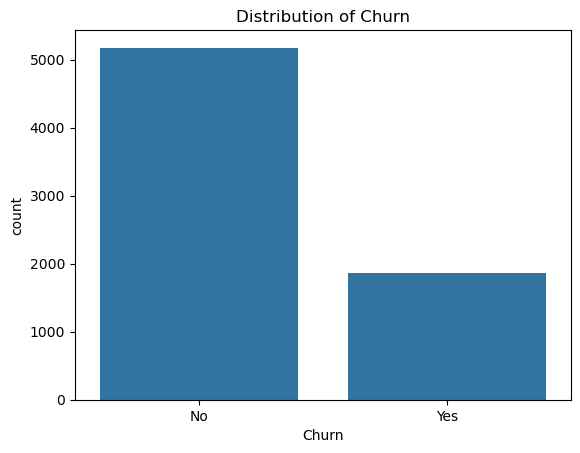

In [8]:
sns.countplot(x = 'Churn', data=df)
plt.title("Distribution of Churn")
plt.show()

From here we can figure out that the dataset is imbalanced dataset.

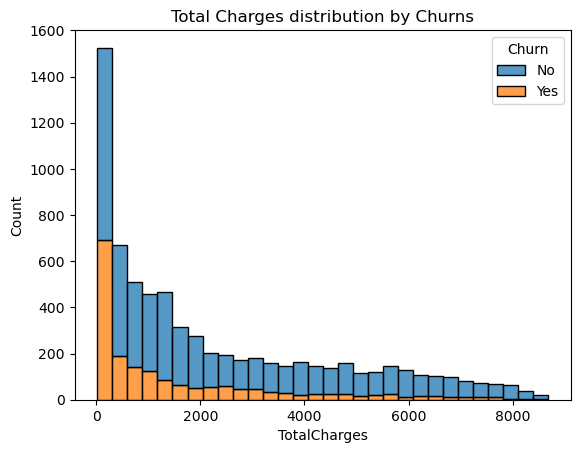

In [9]:
#Distribution of TotalCharges by Churn
sns.histplot(data=df,x = 'TotalCharges', hue='Churn', multiple='stack', bins=30)
plt.title("Total Charges distribution by Churns")
plt.show()

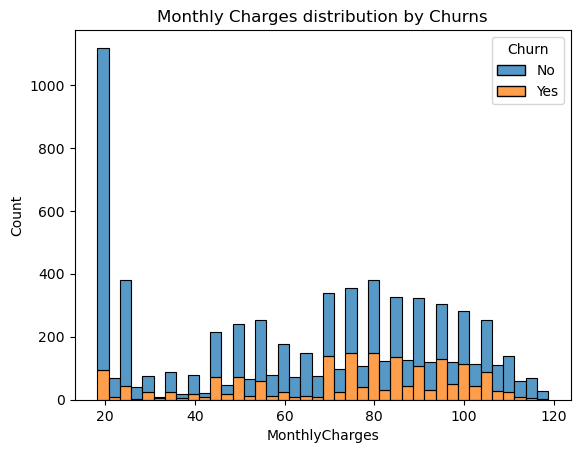

In [10]:
#Distribution of MonthlyCharges by Churn
sns.histplot(data=df,x = 'MonthlyCharges', hue='Churn', multiple='stack', bins=40)
plt.title("Monthly Charges distribution by Churns")
plt.show()

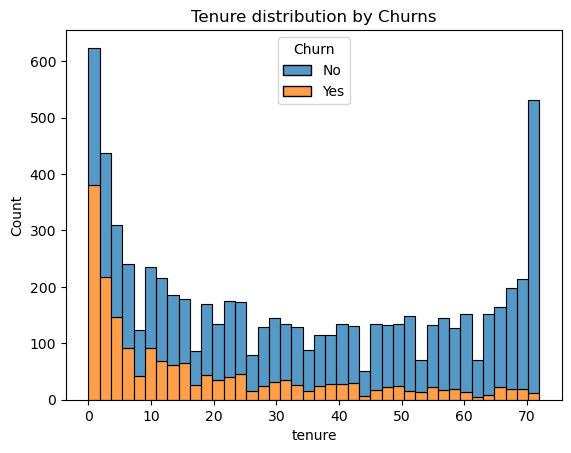

In [11]:
#Distribution of Tenure by Churn
sns.histplot(data=df,x = 'tenure', hue='Churn', multiple='stack', bins=40)
plt.title("Tenure distribution by Churns")
plt.show()

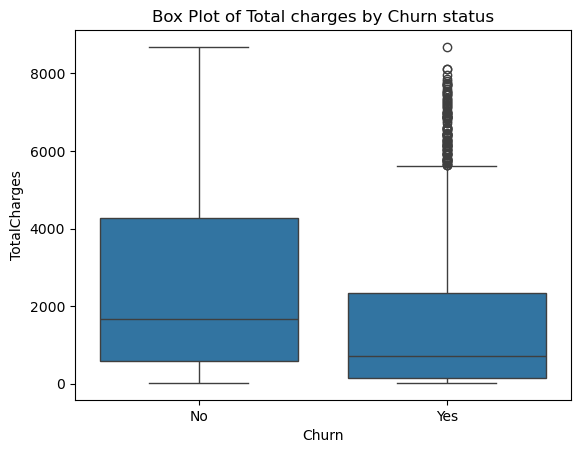

In [12]:
#Box plot for Total charges by Churn status
sns.boxplot(x='Churn',y='TotalCharges',data=df)
plt.title("Box Plot of Total charges by Churn status")
plt.show()

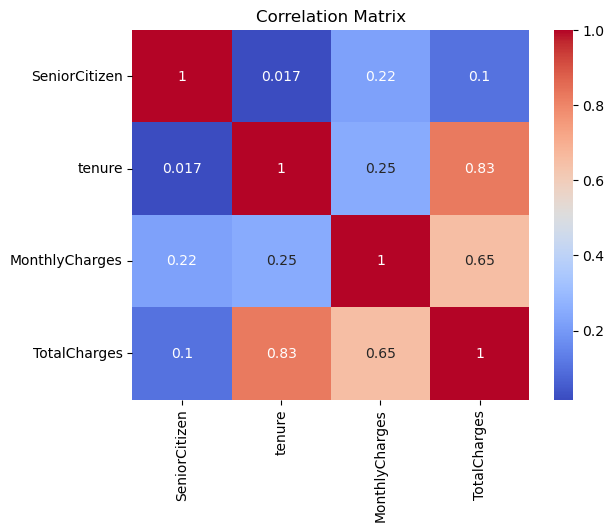

In [13]:
#Correlation matrix

corr_matrix = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

DATA PREPROCESSING 

In [14]:
label_encoders = {}
for column in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [15]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.50,0
7039,2234-XADUH,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.90,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.60,1
7042,3186-AJIEK,1,0,0,0,66,1,0,1,2,...,2,2,2,2,2,1,0,105.65,6844.50,0


MODEL CREATION 

In [27]:
X = df.drop(['customerID','Churn'],axis=1)
y = df['Churn']

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [60]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state=10)

In [61]:
#Feature Scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train,y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test,logreg_pred)

In [63]:
print(f"Logistic Regression Accuracy :{logreg_accuracy*100:.2f}")
print("Logistic Regression Classification Report: ")
print(classification_report(y_test,logreg_pred))

Logistic Regression Accuracy :80.27
Logistic Regression Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1556
           1       0.65      0.56      0.60       557

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.80      0.80      0.80      2113



In [38]:

    gender = int(input("Enter the gender,(0):FEMALE (1):MALE : "))
    SeniorCitizen = int(input("Enter whether you're Senior Citizen or not,(0):NO (1):YES : "))
    Partner = int(input("Enter whether you've Partner or not ,(0):NO (1):YES : "))
    Dependents = int(input("Do you have any dependents? ,(0):NO (1):YES : "))
    tenure = int(input("How long have you stayed with the company(months)? :"))
    PhoneService =int(input("Whether the customer has phone service (Yes/No): "))
    MultipleLines =int(input("Whether the customer has multiple lines (Yes/No): "))
    InternetService =int(input("Who is customer’s internet service provider (DSL(0), Fiberoptic(1), No(2)): "))
    OnlineSecurity =int(input("Whether the customer has online security add-on(Yes/No): "))
    OnlineBackup = int(input("Whether the customer has online backup add-on(Yes/No): "))
    DeviceProtection =int(input("Whether the customer has device protection add-on (Yes/No): "))
    TechSupport = int(input("Whether the customer has tech support add-on(Yes/No): "))
    StreamingTV = int(input("Whether the customer has streaming TV add-on(Yes/No): ")) 
    StreamingMovies = int(input("Whether the customer has streaming movies add-on(Yes/No): ")) 
    Contract = int(input("Type of contract the customer has (Month-to-month(0), One year(1), Two year(2)): "))
    PaperlessBilling =int(input("Whether the customer uses paperless billing(Yes/No): "))
    PaymentMethod =int(input("Customer’s payment method (Electronic check(2),Mailed check(3), Bank transfer (0),etc.): "))
    MonthlyCharges =float(input("Enter the monthly charges: "))
    TotalCharges =float(input("Enter the total charges: ")) 
    user_data = np.array([[gender, SeniorCitizen, Partner, Dependents, tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges]])
    y_input_pred = logreg.predict(user_data)
    print(f"The predicted churn is: {y_input_pred[0]}")

Enter the gender,(0):FEMALE (1):MALE :  0
Enter whether you're Senior Citizen or not,(0):NO (1):YES :  0
Enter whether you've Partner or not ,(0):NO (1):YES :  0
Do you have any dependents? ,(0):NO (1):YES :  0
How long have you stayed with the company(months)? : 45
Whether the customer has phone service (Yes/No):  1
Whether the customer has multiple lines (Yes/No):  0
Who is customer’s internet service provider (DSL(0), Fiberoptic(1), No(2)):  1
Whether the customer has online security add-on(Yes/No):  0
Whether the customer has online backup add-on(Yes/No):  1
Whether the customer has device protection add-on (Yes/No):  0
Whether the customer has tech support add-on(Yes/No):  1
Whether the customer has streaming TV add-on(Yes/No):  1
Whether the customer has streaming movies add-on(Yes/No):  1
Type of contract the customer has (Month-to-month(0), One year(1), Two year(2)):  0
Whether the customer uses paperless billing(Yes/No):  1
Customer’s payment method (Electronic check(2),Mailed

The predicted churn is: 1
